In [1]:
!pip install pandas numpy faker matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from faker import Faker
import random
from datetime import datetime, timedelta

fake = Faker('en_IN')
np.random.seed(42)
random.seed(42)

# Product catalog with cost price
PRODUCTS = {
    'Electronics':    {'items': ['Laptop','Headphones','Tablet','Charger','Speaker'], 'base_price': [45000,2500,18000,500,3000], 'cost_pct': 0.65},
    'Clothing':       {'items': ['T-Shirt','Jeans','Jacket','Saree','Kurta'],          'base_price': [499,1299,2499,1999,899],   'cost_pct': 0.40},
    'Groceries':      {'items': ['Rice 5kg','Oil 1L','Sugar 1kg','Dal 1kg','Atta 5kg'],'base_price': [350,180,55,120,280],       'cost_pct': 0.80},
    'Home Decor':     {'items': ['Lamp','Cushion','Frame','Vase','Clock'],             'base_price': [899,349,599,449,799],      'cost_pct': 0.50},
    'Sports':         {'items': ['Bat','Ball','Shoes','Racket','Gloves'],              'base_price': [599,149,2499,1299,399],    'cost_pct': 0.55},
    'Stationery':     {'items': ['Notebook','Pen Set','Folder','Stapler','Markers'],   'base_price': [99,250,149,199,179],       'cost_pct': 0.35},
}

CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Pune','Kolkata','Jaipur','Ahmedabad','Surat']
CHANNELS = ['Online','In-Store','Mobile App']

rows = []
start_date = datetime(2022, 1, 1)

for i in range(10000):
    category = random.choice(list(PRODUCTS.keys()))
    cat_data  = PRODUCTS[category]
    item_idx  = random.randint(0, len(cat_data['items'])-1)
    product   = cat_data['items'][item_idx]
    base_price= cat_data['base_price'][item_idx]
    cost_pct  = cat_data['cost_pct']

    # Simulate discount: 30% chance of discount, higher for certain categories
    discount_pct = 0
    if random.random() < 0.30:
        discount_pct = random.choice([5,10,15,20,25,30,35,40,45,50])

    selling_price = round(base_price * (1 - discount_pct/100), 2)
    cost_price    = round(base_price * cost_pct, 2)
    quantity      = random.randint(1, 5)
    revenue       = round(selling_price * quantity, 2)
    cost          = round(cost_price * quantity, 2)
    profit        = round(revenue - cost, 2)
    margin_pct    = round((profit / revenue * 100), 2) if revenue > 0 else 0

    txn_date = start_date + timedelta(days=random.randint(0, 730))

    rows.append({
        'transaction_id': f'TXN{100000+i}',
        'customer_id':    f'CUST{random.randint(1000, 3000):04d}',
        'customer_name':  fake.name(),
        'city':           random.choice(CITIES),
        'channel':        random.choice(CHANNELS),
        'category':       category,
        'product':        product,
        'quantity':       quantity,
        'base_price':     base_price,
        'discount_pct':   discount_pct,
        'selling_price':  selling_price,
        'cost_price':     cost_price,
        'revenue':        revenue,
        'cost':           cost,
        'profit':         profit,
        'margin_pct':     margin_pct,
        'date':           txn_date.strftime('%Y-%m-%d'),
    })

df = pd.DataFrame(rows)
df.to_csv('retail_data.csv', index=False)
print(f"Dataset created: {len(df)} rows")
print(df.head())
print(df.dtypes)

Dataset created: 10000 rows
  transaction_id customer_id       customer_name     city     channel  \
0      TXN100000    CUST1285          Xiti Raman    Delhi  Mobile App   
1      TXN100001    CUST1191         Fitan Magar  Chennai      Online   
2      TXN100002    CUST1451  Manthan Contractor   Jaipur  Mobile App   
3      TXN100003    CUST1865    Dalaja Chaudhary     Pune    In-Store   
4      TXN100004    CUST1189        Samesh Singh  Kolkata      Online   

     category   product  quantity  base_price  discount_pct  selling_price  \
0  Stationery  Notebook         2          99            25          74.25   
1  Stationery   Markers         1         179            35         116.35   
2      Sports    Gloves         5         399            20         319.20   
3   Groceries  Rice 5kg         2         350             0         350.00   
4    Clothing     Jeans         3        1299             0        1299.00   

   cost_price  revenue     cost   profit  margin_pct        date

In [3]:
!pip install faker
import sqlite3
import pandas as pd

In [5]:
import sqlite3
import pandas as pd

df = pd.read_csv('retail_data.csv')
conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Data loaded into SQLite")

# ── Query 1: Loss-making product lines (margin erosion) ──
q1 = """
SELECT
    category,
    COUNT(*) AS total_transactions,
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(SUM(profit), 2)  AS total_profit,
    ROUND(AVG(margin_pct), 2) AS avg_margin_pct
FROM transactions
GROUP BY category
ORDER BY avg_margin_pct ASC;
"""
print("\n── Loss-making product lines ──")
result1 = pd.read_sql(q1, conn)
print(result1.to_string())
result1.to_csv('sql_margin_by_category.csv', index=False)

# ── Query 2: Products with >40% discount causing losses ──
q2 = """
SELECT
    product,
    category,
    COUNT(*) AS discounted_txns,
    ROUND(AVG(discount_pct), 1) AS avg_discount,
    ROUND(SUM(profit), 2) AS total_profit,
    ROUND(AVG(margin_pct), 2) AS avg_margin
FROM transactions
WHERE discount_pct > 40
GROUP BY product, category
ORDER BY total_profit ASC
LIMIT 15;
"""
print("\n── High-discount loss products ──")
result2 = pd.read_sql(q2, conn)
print(result2.to_string())
result2.to_csv('sql_high_discount_losses.csv', index=False)

# ── Query 3: Revenue and profit by channel ──
q3 = """
SELECT
    channel,
    ROUND(SUM(revenue), 2) AS total_revenue,
    ROUND(SUM(profit), 2)  AS total_profit,
    ROUND(AVG(margin_pct), 2) AS avg_margin
FROM transactions
GROUP BY channel
ORDER BY total_revenue DESC;
"""
print("\n── Channel performance ──")
print(pd.read_sql(q3, conn).to_string())

# ── Query 4: Monthly revenue trend ──
q4 = """
SELECT
    SUBSTR(date, 1, 7) AS month,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(profit), 2)  AS profit
FROM transactions
GROUP BY month
ORDER BY month;
"""
monthly = pd.read_sql(q4, conn)
monthly.to_csv('sql_monthly_trend.csv', index=False)
print("\n── Monthly trend saved ──")

# ── Query 5: Top 10 profitable products ──
q5 = """
SELECT product, category,
    ROUND(SUM(profit),2) AS total_profit,
    ROUND(AVG(margin_pct),2) AS avg_margin
FROM transactions
GROUP BY product, category
ORDER BY total_profit DESC LIMIT 10;
"""
print("\n── Top profitable products ──")
print(pd.read_sql(q5, conn).to_string())

conn.close()

Data loaded into SQLite

── Loss-making product lines ──
      category  total_transactions  total_revenue  total_profit  avg_margin_pct
0    Groceries                1645      886729.75     116769.75            9.92
1  Electronics                1605    57373475.00   16640575.00           25.66
2       Sports                1661     4475398.70    1780758.95           37.88
3   Home Decor                1676     2855886.35    1294018.35           43.35
4     Clothing                1728     6833180.20    3839300.60           54.27
5   Stationery                1685      804719.20     496975.05           60.16

── High-discount loss products ──
       product     category  discounted_txns  avg_discount  total_profit  avg_margin
0       Laptop  Electronics               26          47.7    -414000.00      -24.54
1       Tablet  Electronics               19          47.1    -123300.00      -23.16
2   Headphones  Electronics               30          47.3     -34125.00      -23.70
3      S

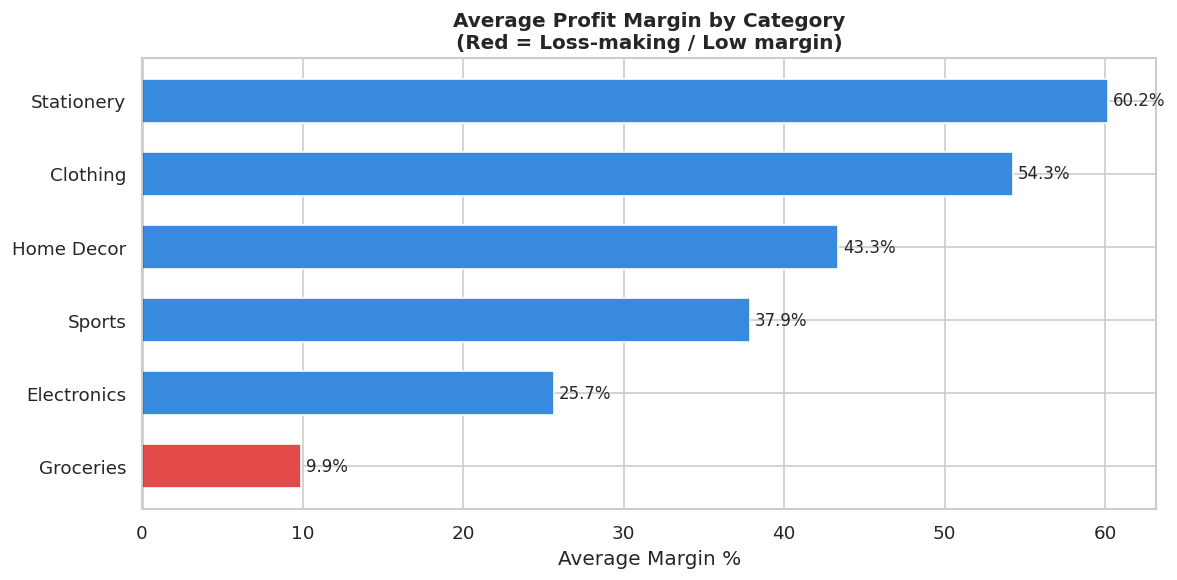

Saved: chart_margin_by_category.png


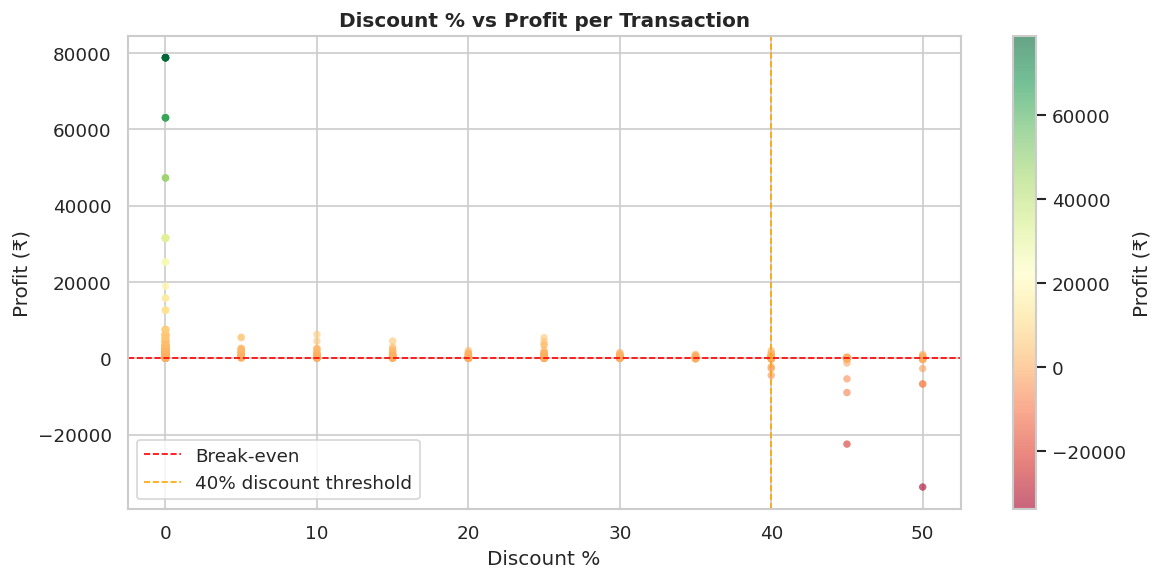

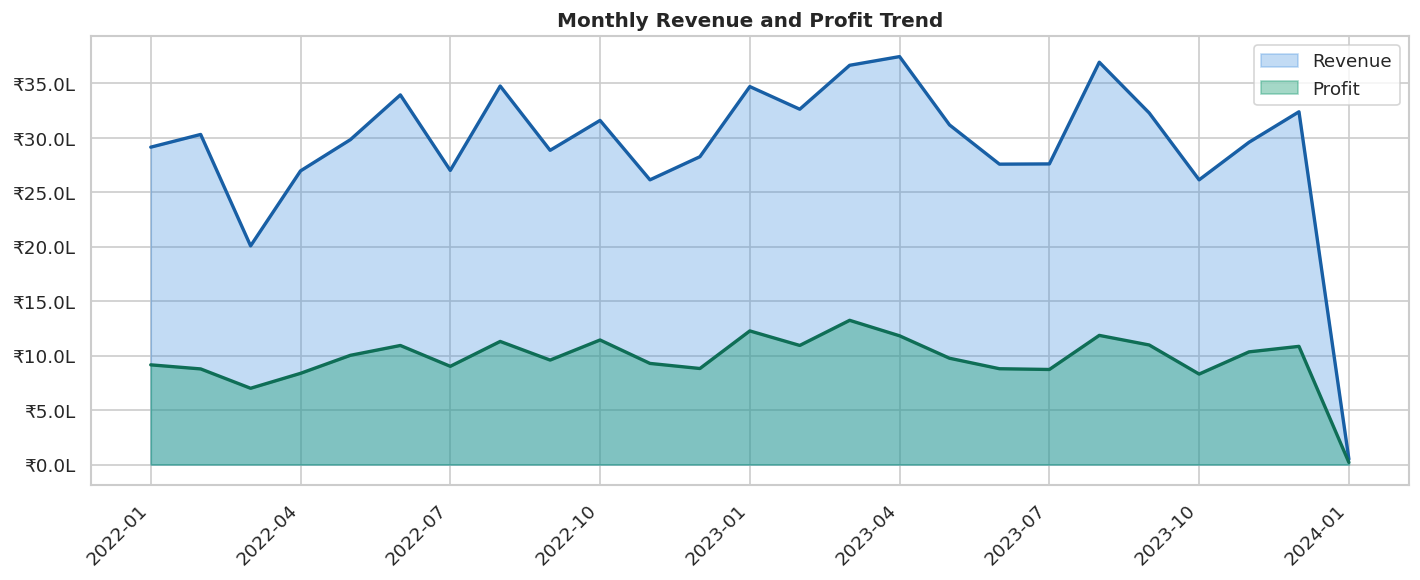


── Pricing Strategy Simulation ──
Current profit (>40% disc transactions): ₹-556,590
Simulated profit (no discount):          ₹2,247,883
Potential savings:                       ₹2,804,474  (28.0L)


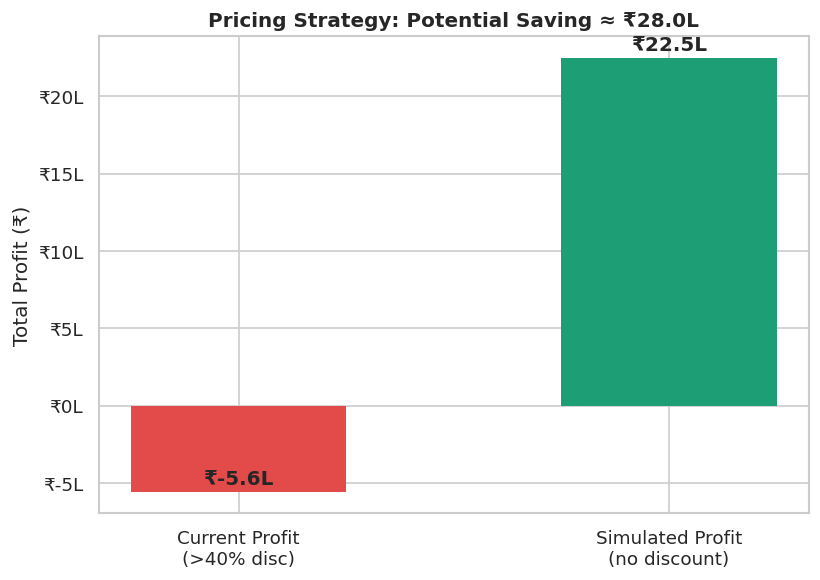

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('retail_data.csv')
df['date'] = pd.to_datetime(df['date'])

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Chart 1: Margin by Category (loss-making lines) ──
fig, ax = plt.subplots(figsize=(10, 5))
cat_margin = df.groupby('category')['margin_pct'].mean().sort_values()
colors = ['#E24B4A' if v < 15 else '#378ADD' for v in cat_margin.values]
bars = ax.barh(cat_margin.index, cat_margin.values, color=colors, height=0.6)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Average Margin %')
ax.set_title('Average Profit Margin by Category\n(Red = Loss-making / Low margin)', fontweight='bold')
for bar, val in zip(bars, cat_margin.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart_margin_by_category.png')
plt.show()
print("Saved: chart_margin_by_category.png")

# ── Chart 2: Discount vs Profit scatter ──
fig, ax = plt.subplots(figsize=(10, 5))
sample = df.sample(1000, random_state=42)
scatter = ax.scatter(sample['discount_pct'], sample['profit'],
                     c=sample['profit'], cmap='RdYlGn',
                     alpha=0.6, edgecolors='none', s=20)
ax.axhline(y=0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax.axvline(x=40, color='orange', linewidth=1, linestyle='--', label='40% discount threshold')
ax.set_xlabel('Discount %')
ax.set_ylabel('Profit (₹)')
ax.set_title('Discount % vs Profit per Transaction', fontweight='bold')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Profit (₹)')
plt.tight_layout()
plt.savefig('chart_discount_vs_profit.png')
plt.show()

# ── Chart 3: Monthly revenue + profit trend ──
monthly = df.groupby(df['date'].dt.to_period('M')).agg(
    revenue=('revenue','sum'), profit=('profit','sum')).reset_index()
monthly['date_str'] = monthly['date'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.3, color='#378ADD', label='Revenue')
ax.fill_between(range(len(monthly)), monthly['profit'], alpha=0.4, color='#1D9E75', label='Profit')
ax.plot(range(len(monthly)), monthly['revenue'], color='#185FA5', linewidth=2)
ax.plot(range(len(monthly)), monthly['profit'],  color='#0F6E56', linewidth=2)
ax.set_xticks(range(0, len(monthly), 3))
ax.set_xticklabels(monthly['date_str'].iloc[::3], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.1f}L'))
ax.set_title('Monthly Revenue and Profit Trend', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart_monthly_trend.png')
plt.show()

# ── Chart 4: Profit loss from high discounts (pricing strategy) ──
high_disc = df[df['discount_pct'] > 40]
low_disc  = df[df['discount_pct'] <= 40]

actual_profit     = high_disc['profit'].sum()
no_discount_revenue = (high_disc['selling_price'] / (1 - high_disc['discount_pct']/100)) * high_disc['quantity']
simulated_profit  = (no_discount_revenue - high_disc['cost']).sum()
savings           = simulated_profit - actual_profit

print(f"\n── Pricing Strategy Simulation ──")
print(f"Current profit (>40% disc transactions): ₹{actual_profit:,.0f}")
print(f"Simulated profit (no discount):          ₹{simulated_profit:,.0f}")
print(f"Potential savings:                       ₹{savings:,.0f}  ({savings/1e5:.1f}L)")

fig, ax = plt.subplots(figsize=(7, 5))
labels  = ['Current Profit\n(>40% disc)', 'Simulated Profit\n(no discount)']
values  = [actual_profit, simulated_profit]
colors  = ['#E24B4A', '#1D9E75']
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='none')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'₹{val/1e5:.1f}L', ha='center', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e5:.0f}L'))
ax.set_title(f'Pricing Strategy: Potential Saving ≈ ₹{savings/1e5:.1f}L', fontweight='bold')
ax.set_ylabel('Total Profit (₹)')
plt.tight_layout()
plt.savefig('chart_pricing_strategy.png')
plt.show()


RFM base table:
       recency  frequency   monetary
count  1989.00    1989.00    1989.00
mean    140.06       5.03   36817.19
std     129.93       2.22   57050.75
min       1.00       1.00     149.00
25%      41.00       3.00    6037.10
50%     105.00       5.00   13190.40
75%     198.00       7.00   36000.00
max     726.00      14.00  395456.50

Segment distribution:
Segment
Loyal Customers        448
Lost Customers         382
Needs Attention        328
Champions              269
At Risk                254
New Customers          216
Potential Loyalists     55
Cant Lose Them          37
Name: count, dtype: int64

Saved: rfm_output.csv


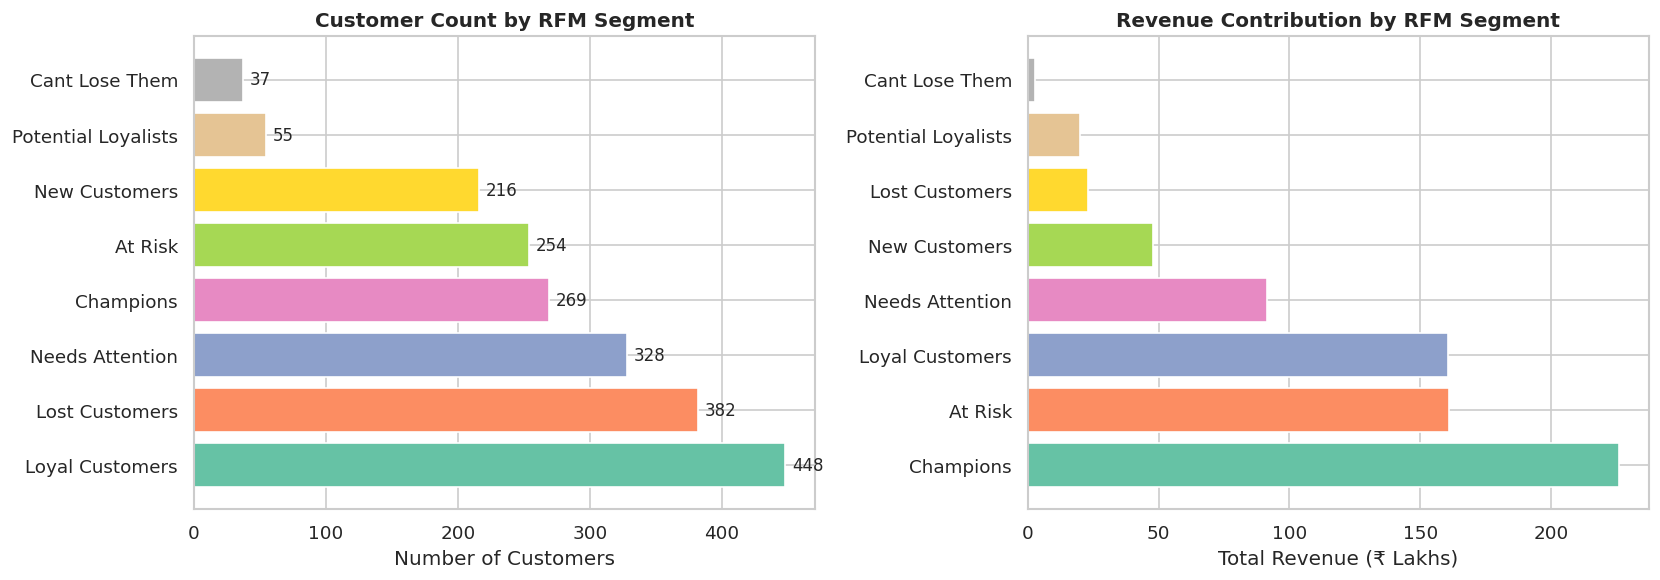

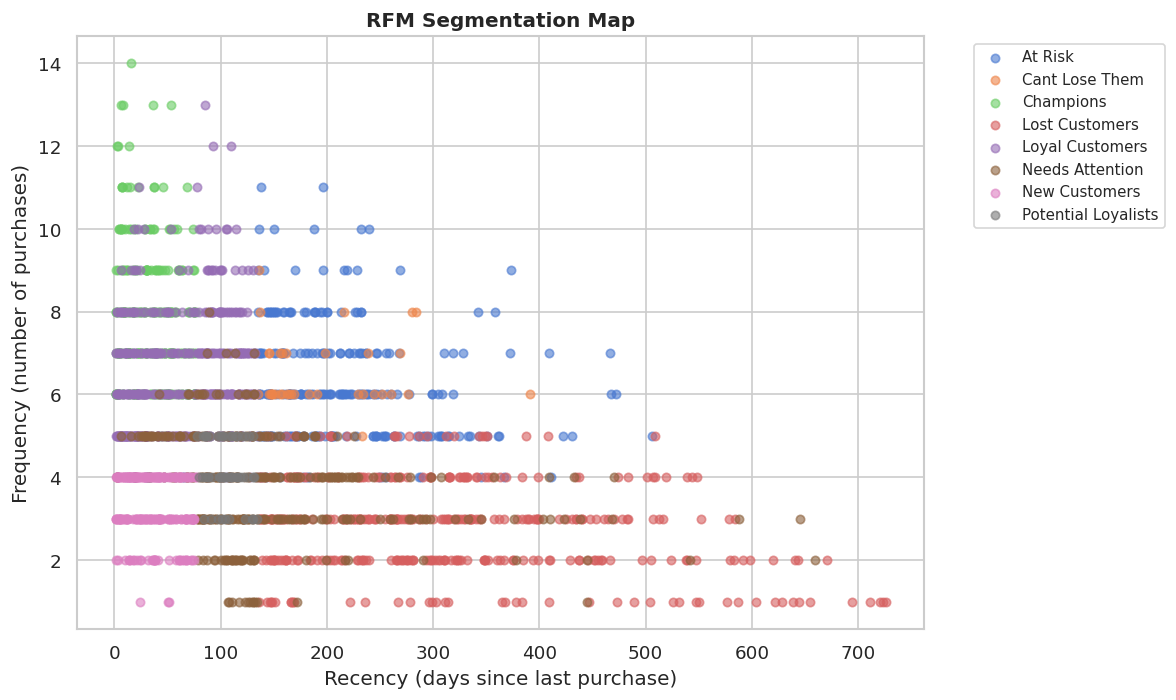

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_data.csv')
df['date'] = pd.to_datetime(df['date'])

# Reference date: day after last transaction
reference_date = df['date'].max() + pd.Timedelta(days=1)

# ── Step 1: Compute RFM values per customer ──
rfm = df.groupby('customer_id').agg(
    recency   = ('date', lambda x: (reference_date - x.max()).days),
    frequency = ('transaction_id', 'count'),
    monetary  = ('revenue', 'sum')
).reset_index()

print("RFM base table:")
print(rfm.describe().round(2))

# ── Step 2: Score each metric 1-5 (5 = best) ──
rfm['R_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['Total_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# ── Step 3: Assign segment labels ──
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    total = r + f + m
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and total >= 10:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and total <= 6:
        return 'Lost Customers'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment, axis=1)

print("\nSegment distribution:")
print(rfm['Segment'].value_counts())

rfm.to_csv('rfm_output.csv', index=False)
print("\nSaved: rfm_output.csv")

# ── Chart: Segment distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(seg_counts)))
axes[0].barh(seg_counts.index, seg_counts.values, color=colors)
axes[0].set_xlabel('Number of Customers')
axes[0].set_title('Customer Count by RFM Segment', fontweight='bold')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

seg_value = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=False)
axes[1].barh(seg_value.index, seg_value.values / 1e5, color=colors[:len(seg_value)])
axes[1].set_xlabel('Total Revenue (₹ Lakhs)')
axes[1].set_title('Revenue Contribution by RFM Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_rfm_segments.png')
plt.show()

# ── Scatter: Recency vs Frequency colored by segment ──
fig, ax = plt.subplots(figsize=(10, 6))
for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['recency'], grp['frequency'], label=seg, alpha=0.6, s=25)
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Frequency (number of purchases)')
ax.set_title('RFM Segmentation Map', fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart_rfm_map.png')
plt.show()


In [8]:
from google.colab import files
files.download('retail_data.csv')
files.download('rfm_output.csv')
files.download('sql_monthly_trend.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>